# Notebook 01 — Exploration du Dataset
**Projet 14 : Analyse intelligente des notes des étudiants**
Dataset : Students Performance in Exams (Kaggle)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/raw/StudentsPerformance.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
# Informations générales
print('=== Types des colonnes ===')
print(df.dtypes)
print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())
print('\n=== Doublons ===')
print(f'Nombre de doublons : {df.duplicated().sum()}')

=== Types des colonnes ===
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

=== Valeurs manquantes ===
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

=== Doublons ===
Nombre de doublons : 0


In [3]:
# Statistiques descriptives des scores numériques
df[['math score', 'reading score', 'writing score']].describe().round(2)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


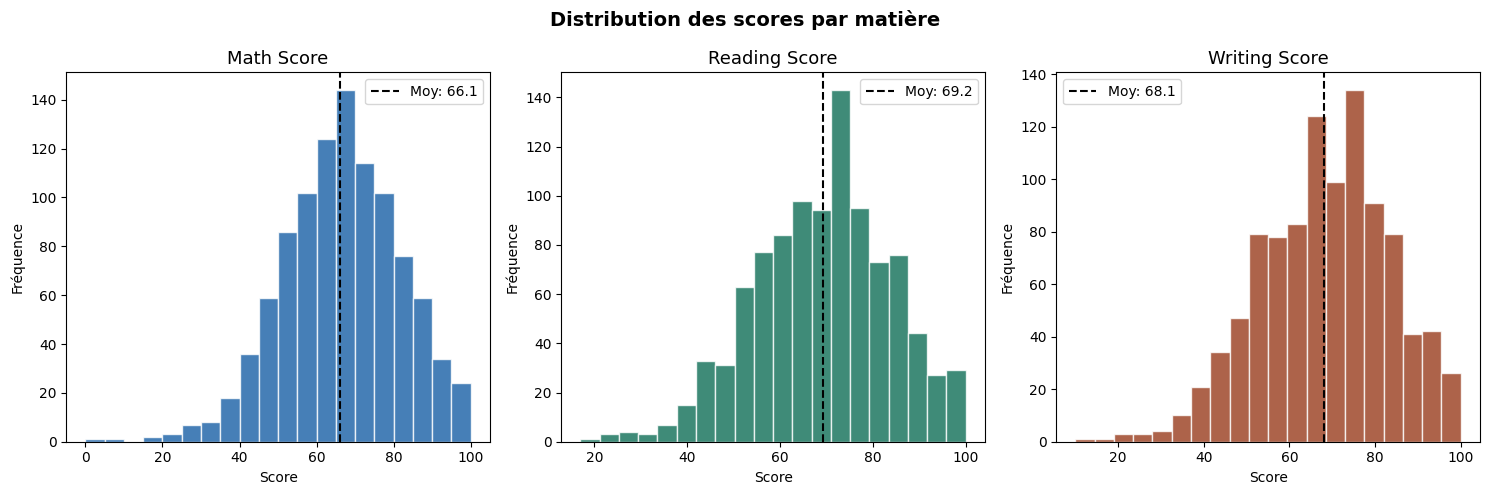

In [4]:
# Distribution des scores
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols = ['math score', 'reading score', 'writing score']
colors = ['#185FA5', '#0F6E56', '#993C1D']
for ax, col, color in zip(axes, cols, colors):
    ax.hist(df[col], bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', label=f'Moy: {df[col].mean():.1f}')
    ax.set_title(col.title(), fontsize=13)
    ax.set_xlabel('Score')
    ax.set_ylabel('Fréquence')
    ax.legend()
plt.suptitle('Distribution des scores par matière', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/distribution_scores.png', dpi=150)
plt.show()

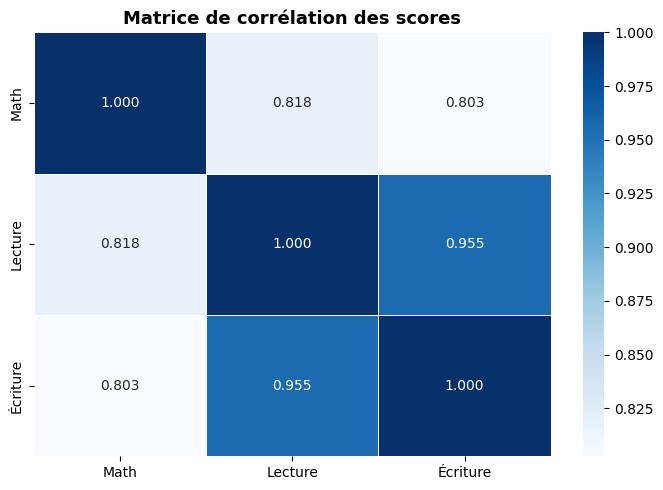


Observation : les trois scores sont fortement corrélés (r > 0.80)
=> La PCA va pouvoir réduire efficacement la dimensionnalité.


In [5]:
# Matrice de corrélation
corr = df[['math score', 'reading score', 'writing score']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5,
            xticklabels=['Math', 'Lecture', 'Écriture'],
            yticklabels=['Math', 'Lecture', 'Écriture'])
plt.title('Matrice de corrélation des scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150)
plt.show()
print('\nObservation : les trois scores sont fortement corrélés (r > 0.80)')
print('=> La PCA va pouvoir réduire efficacement la dimensionnalité.')

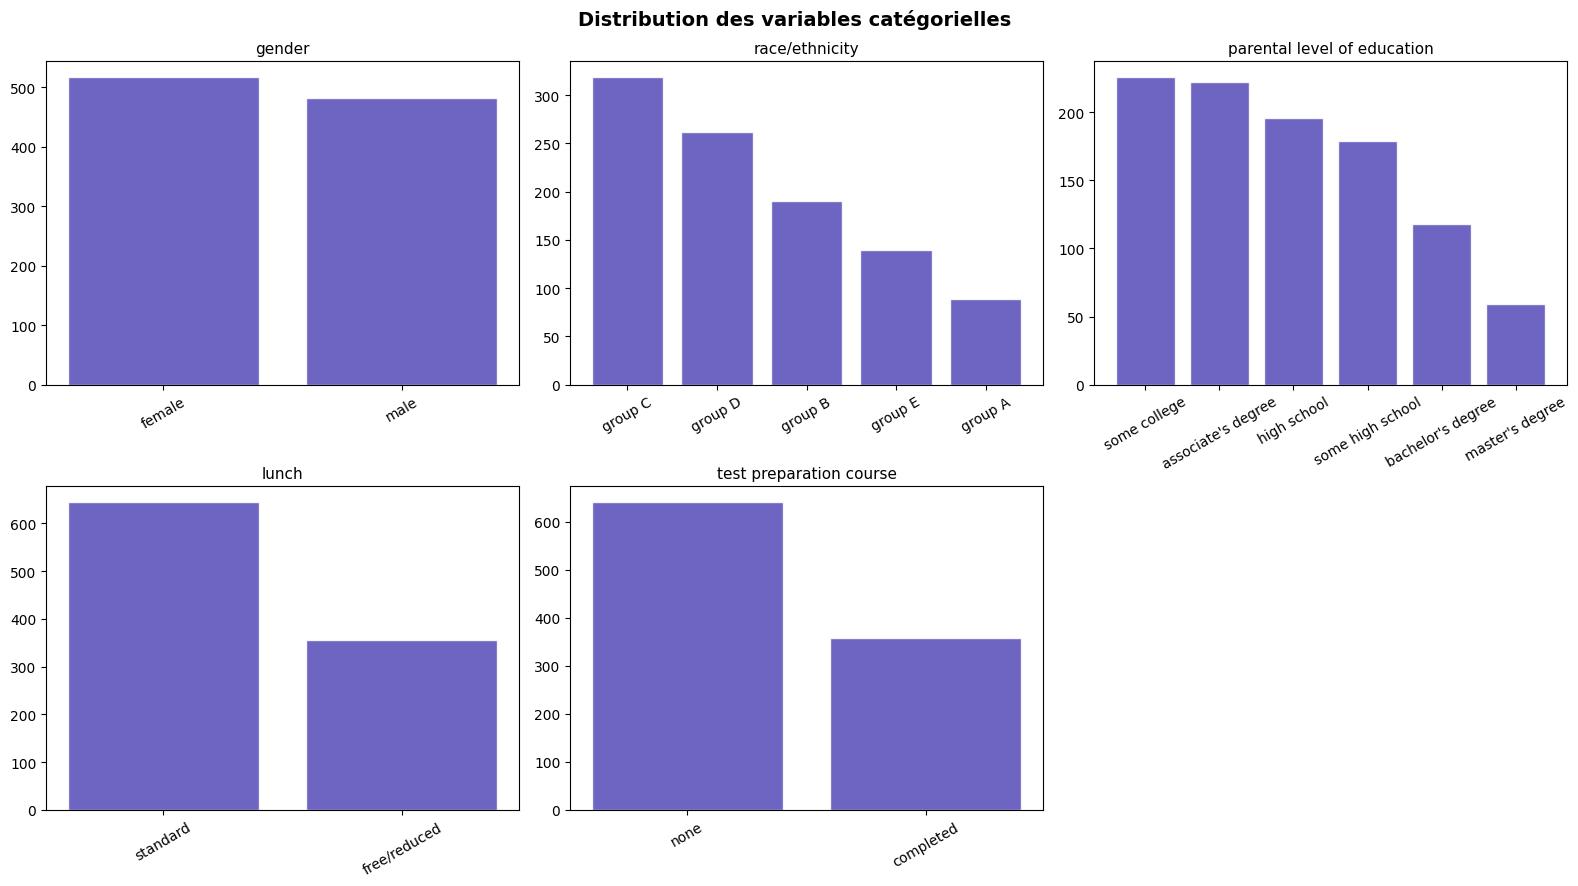

In [6]:
# Variables catégorielles
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='#534AB7', alpha=0.85, edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
axes[5].axis('off')
plt.suptitle('Distribution des variables catégorielles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/categorical_distribution.png', dpi=150)
plt.show()